In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def split_data(data, train_size=0.6, test_size=0.2, val_size=0.2, random_state=42, bias_row=False):
    np.random.seed(random_state)
    np.random.shuffle(data)
    
    x,y = data[:,:30], data[:,30]
    data_len = x.shape[0]
    if(bias_row):
        x = np.concatenate((np.ones((x.shape[0], 1)), x), axis=1)
    return x[:int(train_size*data_len)], x[int(train_size*data_len):int((train_size+test_size)*data_len)], x[int((train_size+test_size)*data_len):int((train_size+test_size+val_size)*data_len)], y[:int(train_size*data_len)], y[int(train_size*data_len):int((train_size+test_size)*data_len)], y[int((train_size+test_size)*data_len):int((train_size+test_size+val_size)*data_len)]

In [3]:
data = np.loadtxt('phishing.data', delimiter=',').astype(int)
x_train, x_test, x_val, y_train, y_test, y_val = split_data(data)

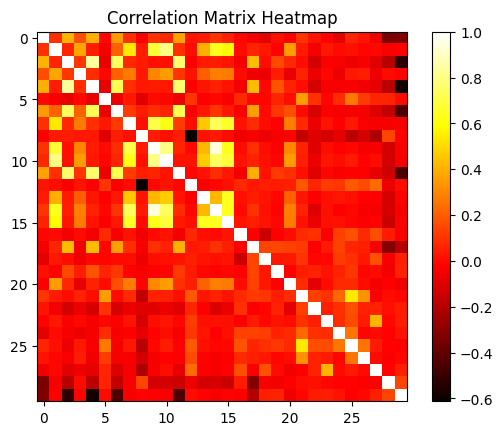

In [97]:

corr_matrix = np.corrcoef(x_train, rowvar=False)
plt.imshow(corr_matrix, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Correlation Matrix Heatmap')
plt.show()


In [4]:
class linear_kernel:
    def __call__(self, x1, x2):
        return np.dot(x1, x2)
    def gram_matrix(self, X):
        return np.dot(X, X.T)
class exponential_kernel:
    def __init__(self, gamma=1.0):
        self.gamma = gamma
    def __call__(self, x1, x2):
        return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
    def gram_matrix(self, X):
        sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * np.dot(X, X.T)
        sq_dists = np.maximum(sq_dists, 0.0)
        return np.exp(-self.gamma * sq_dists)

In [ ]:
class SVM:
    def __init__( self, C=1.0, kernel=linear_kernel(), tol=1e-3, max_passes=3, verbose=False, log=False, log_interval=50):
        self.C = C
        self.kernel = kernel
        self.tol = tol
        self.max_passes = max_passes
        self.verbose = verbose
        self.log = log
        self.log_interval = log_interval
        self.objective_history = []
        self.accuracy_history = []
    def objective_function(self):
        
        ay = self.alpha * self.y_train
        return np.sum(self.alpha) - 0.5 * ay @ self.gram_matrix @ ay
    def predict(self, X):
        if(isinstance(self.kernel, linear_kernel)):
            return np.sign(X @ self.w + self.b)
        else:
            sv = self.alpha > 1e-5
            alpha_sv = self.alpha[sv]
            y_sv = self.y_train[sv]
            X_sv = self.x_train[sv]
            results = []

            for x in X:
                k = np.array([self.kernel(x_i, x) for x_i in X_sv])
                results.append(np.sum(alpha_sv * y_sv * k) + self.b)
            return np.sign(np.array(results))
    
    def calculate_error_cache(self):
        self.error_cache = (
            self.gram_matrix @ (self.alpha * self.y_train) + self.b - self.y_train
        )
    def update_error_cache(self, i, j, alpha_i_old, alpha_j_old, b_old):
        delta_alpha_i = self.alpha[i] - alpha_i_old
        delta_alpha_j = self.alpha[j] - alpha_j_old
        delta_b = self.b - b_old
        self.error_cache += (
            delta_alpha_i * self.y_train[i] * self.gram_matrix[i, :] + 
            delta_alpha_j * self.y_train[j] * self.gram_matrix[j, :] +
            delta_b
        )
    def fit(self, x_train, y_train):
        n_samples, n_features = x_train.shape
        self.x_train = x_train
        self.y_train = y_train
        self.alpha = np.zeros(n_samples)
        self.b = 0
        self.gram_matrix = np.zeros((n_samples, n_samples))
        self.gram_matrix = self.kernel.gram_matrix(self.x_train)
        self.calculate_error_cache()
        self.obj_new = self.objective_function()
        passes = 0
        epoch = 0
        while passes < self.max_passes:
            epoch += 1
            changed_alphas = 0
            for i in range(n_samples):
                # Warunek KKT
                if (((self.y_train[i] * self.error_cache[i] < -self.tol) and self.alpha[i] < self.C)
                or
                ((self.y_train[i] * self.error_cache[i] > self.tol) and self.alpha[i] > 0)):
                    
                    j = np.random.randint(0, n_samples)
                    while j == i:
                        j = np.random.randint(0, n_samples)
                    alpha_i_old = self.alpha[i]
                    alpha_j_old = self.alpha[j]
                    # Liczymy L i H by alpha[j] dalej spełniało warunek 0 <= alpha[j] <= C, oraz sum(y[i] * alpha[i]) = 0
                    if(self.y_train[i] != self.y_train[j]):
                        L = max(0, self.alpha[j] - self.alpha[i])
                        H = min(self.C, self.C + self.alpha[j] - self.alpha[i])
                    else:
                        L = max(0, self.alpha[i] + self.alpha[j] - self.C)
                        H = min(self.C, self.alpha[i] + self.alpha[j]) 
                    if L == H:
                        continue
                    eta = (2 * self.gram_matrix[i,j]
                            - self.gram_matrix[i,i] 
                            - self.gram_matrix[j,j])
                    if eta >= 0:
                        continue
                    self.alpha[j] -= self.y_train[j] * (self.error_cache[i] - self.error_cache[j]) / eta
                    self.alpha[j] = np.clip(self.alpha[j], L, H)
                    
                    # Jeśli alpha[j] nie zmieniło się znacząco to nie aktualizujemy alpha[i] i biasu.
                    if abs(self.alpha[j] - alpha_j_old) < 1e-5:
                        continue
                    # Aktualizujemy alpha[i] tak by spełniało warunek sum(y[i] * alpha[i]) = 0
                    self.alpha[i] += self.y_train[i] * self.y_train[j] * (alpha_j_old - self.alpha[j])
                    b_old = self.b
                    # Liczymy kandydatów na bias
                    b1 = (self.b
                        - self.error_cache[i]
                        - self.y_train[i] * (self.alpha[i] - alpha_i_old) * self.gram_matrix[i,i]
                        - self.y_train[j] * (self.alpha[j] - alpha_j_old) * self.gram_matrix[i,j])
                    b2 = (self.b
                        - self.error_cache[j]
                        - self.y_train[i] * (self.alpha[i] - alpha_i_old) * self.gram_matrix[i,j]
                        - self.y_train[j] * (self.alpha[j] - alpha_j_old) * self.gram_matrix[j,j])
                    
                    # Jeśli dla alpha[i] lub alpha[j] zachodzi 0 < alpha < C to punkt leży dokladnie na marginesie
                    # więc bierzemy bias obliczony dla niego
                    # W przeciwnym wypadku bierzemy średnią z obu kandydatów
                    
                    if 0 < self.alpha[i] < self.C:
                        self.b = b1
                    elif 0 < self.alpha[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
                    self.update_error_cache(i, j, alpha_i_old, alpha_j_old, b_old)
                    
                    changed_alphas += 1
            if( epoch % self.log_interval == 0):
                self.obj_old= self.obj_new
                self.obj_new= self.objective_function()
                if self.log:
                    self.w = (self.alpha * self.y_train) @ self.x_train   
                    accuracy= np.mean(self.predict(self.x_train) == self.y_train)
                    if self.verbose:
                        print(f'objective: {objective_val:.4f}, Training Accuracy: {accuracy:.4f}')
                    self.objective_history.append(objective_val)
                    self.accuracy_history.append(accuracy)
                # Zatrzymujemy, gdy funkcja celu stabilizuje się
                relative_change = abs(self.obj_new - self.obj_old) / (abs(self.obj_old) + 1e-8)
                if relative_change < 1e-4:
                    stable_epochs += 1
                else:
                    stable_epochs = 0

                if stable_epochs >= 5:
                    break
            #Zatrzymujemy, gdy nie ma zmian w alpha
            if changed_alphas == 0:
                passes += 1
            else:
                passes = 0
        self.w = (self.alpha * self.y_train) @ self.x_train    
       
        if self.verbose:
            objective_val = self.objective_function()
            accuracy= np.mean(self.predict(self.x_train) == self.y_train)
            print(f'Training completed. Objective: {objective_val:.4f}, Training Accuracy: {accuracy:.4f}')     
                    

In [ ]:
c_vals = [0.1, 1, 10]
tol_vals = [1e-4, 1e-3, 0.1]
gamma_vals = [0.01, 0.1]
fracs = [0.01, 0.02, 0.03, 0.125,0.625, 1]

In [ ]:

stats_lin = {}
for C in c_vals:
    for tol in tol_vals:
        model = SVM(C=C, kernel=linear_kernel(), tol=tol, log_interval=50)
        stats_lin[(C, tol)] = []
        for frac in fracs:
            n_samples = int(frac * x_train.shape[0])
            model.fit(x_train[:n_samples], y_train[:n_samples])
            val_accuracy = np.mean(model.predict(x_val) == y_val)
            stats_lin[(C, tol)].append((frac, val_accuracy))
            print(f'C: {C}, tol: {tol}, fraction: {frac:.3f}, Validation Accuracy: {val_accuracy:.4f}')
            

C: 0.1, tol: 0.0001, fraction: 0.010, Validation Accuracy: 0.9059
C: 0.1, tol: 0.0001, fraction: 0.020, Validation Accuracy: 0.9104
C: 0.1, tol: 0.0001, fraction: 0.030, Validation Accuracy: 0.9154
C: 0.1, tol: 0.0001, fraction: 0.125, Validation Accuracy: 0.9181
C: 0.1, tol: 0.0001, fraction: 0.625, Validation Accuracy: 0.9254
C: 0.1, tol: 0.0001, fraction: 1.000, Validation Accuracy: 0.9303
C: 0.1, tol: 0.001, fraction: 0.010, Validation Accuracy: 0.9055
C: 0.1, tol: 0.001, fraction: 0.020, Validation Accuracy: 0.9104
C: 0.1, tol: 0.001, fraction: 0.030, Validation Accuracy: 0.9154
C: 0.1, tol: 0.001, fraction: 0.125, Validation Accuracy: 0.9190
C: 0.1, tol: 0.001, fraction: 0.625, Validation Accuracy: 0.9263
C: 0.1, tol: 0.001, fraction: 1.000, Validation Accuracy: 0.9299
C: 0.1, tol: 0.1, fraction: 0.010, Validation Accuracy: 0.9082
C: 0.1, tol: 0.1, fraction: 0.020, Validation Accuracy: 0.9095
C: 0.1, tol: 0.1, fraction: 0.030, Validation Accuracy: 0.9159
C: 0.1, tol: 0.1, fractio

In [ ]:
stats_exp = {}
for C in c_vals:
    for tol in tol_vals:
        for gamma in gamma_vals:
            model = SVM(C=C, kernel=exponential_kernel(gamma=gamma), tol=tol, log_interval=50)
            stats_exp[(C, tol, gamma)] = []
            for frac in fracs:
                n_samples = int(frac * x_train.shape[0])
                model.fit(x_train[:n_samples], y_train[:n_samples])
                val_accuracy = np.mean(model.predict(x_val) == y_val)
                stats_exp[(C, tol, gamma)].append((frac, val_accuracy))
                print(f'C: {C}, tol: {tol}, gamma: {gamma}, fraction: {frac:.3f}, Validation Accuracy: {val_accuracy:.4f}')

C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 0.010, Validation Accuracy: 0.5432
C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 0.020, Validation Accuracy: 0.5432
C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 0.030, Validation Accuracy: 0.5441
C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 0.125, Validation Accuracy: 0.9055
C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 0.625, Validation Accuracy: 0.9168
C: 0.1, tol: 0.0001, gamma: 0.01, fraction: 1.000, Validation Accuracy: 0.9199
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 0.010, Validation Accuracy: 0.5432
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 0.020, Validation Accuracy: 0.5432
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 0.030, Validation Accuracy: 0.5780
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 0.125, Validation Accuracy: 0.8281
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 0.625, Validation Accuracy: 0.9240
C: 0.1, tol: 0.0001, gamma: 0.1, fraction: 1.000, Validation Accuracy: 0.9353
C: 0.1, tol: 0.001, gamma: 0.01, fraction: 0.010, Validati

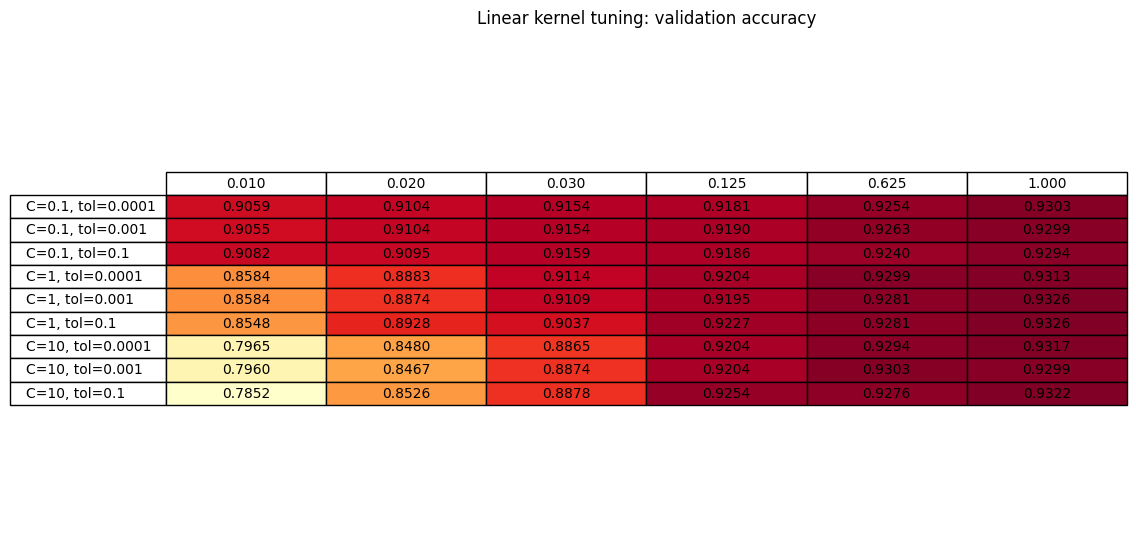

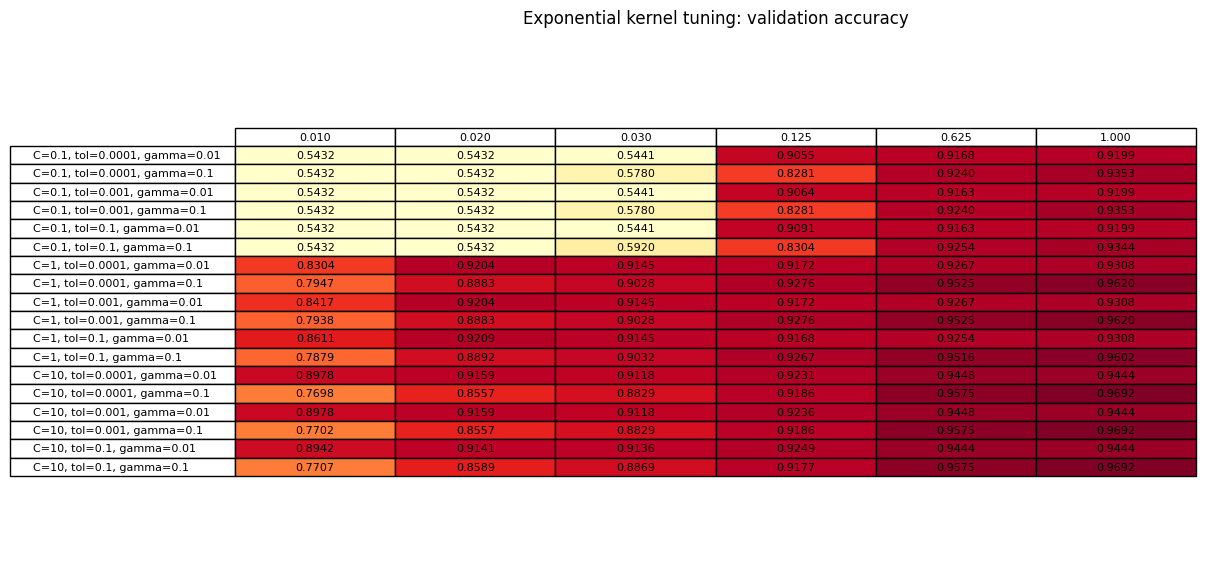

In [ ]:

row_keys = sorted(stats_lin.keys())
row_labels = [f"C={C}, tol={tol}" for C, tol in row_keys]

matrix = []
for key in row_keys:
    row = [next(acc for frac, acc in stats_lin[key] if frac == f) for f in fracs]
    matrix.append(row)

acc = np.array(matrix)
normed = (acc - acc.min()) / (acc.max() - acc.min() + 1e-12)

cmap = plt.get_cmap("YlOrRd")
cell_colors = [[cmap(v) for v in row] for row in normed]

fig, ax = plt.subplots(figsize=(len(fracs) * 1.4 + 4, len(row_labels) * 0.35 + 3))
ax.axis("off")

cell_text = [[f"{value:.4f}" for value in row] for row in matrix]
table = ax.table(
    cellText=cell_text,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=[f"{frac:.3f}" for frac in fracs],
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
ax.set_title("Linear kernel tuning: validation accuracy", pad=20)
plt.show()

row_keys_exp = sorted(stats_exp.keys())
row_labels_exp = [f"C={C}, tol={tol}, gamma={gamma}" for C, tol, gamma in row_keys_exp]

matrix_exp = []
for key in row_keys_exp:
    row = [next(acc for frac, acc in stats_exp[key] if frac == f) for f in fracs]
    matrix_exp.append(row)

acc_exp = np.array(matrix_exp)
normed_exp = (acc_exp - acc_exp.min()) / (acc_exp.max() - acc_exp.min() + 1e-12)
cell_colors_exp = [[cmap(v) for v in row] for row in normed_exp]

fig, ax = plt.subplots(figsize=(len(fracs) * 1.4 + 4, len(row_labels_exp) * 0.14 + 4))
ax.axis("off")

cell_text_exp = [[f"{value:.4f}" for value in row] for row in matrix_exp]
table = ax.table(
    cellText=cell_text_exp,
    cellColours=cell_colors_exp,
    rowLabels=row_labels_exp,
    colLabels=[f"{frac:.3f}" for frac in fracs],
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.1)
ax.set_title("Exponential kernel tuning: validation accuracy", pad=20)
plt.show()

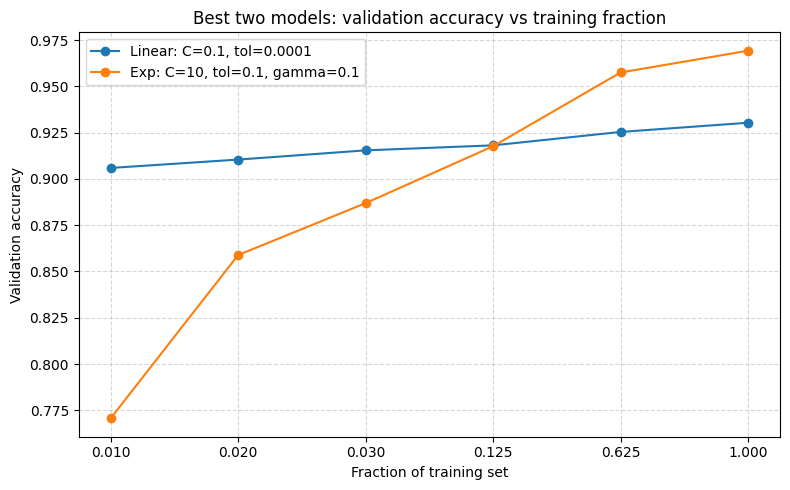

In [ ]:
best_lin = (0.1, 1e-4)
best_exp = (10, 0.1, 0.1)

fractions_plot = sorted({frac for values in stats_lin.values() for frac, _ in values})
acc_best_lin = [next(acc for frac, acc in stats_lin[best_lin] if frac == f) for f in fractions_plot]
acc_best_exp = [next(acc for frac, acc in stats_exp[best_exp] if frac == f) for f in fractions_plot]

x_positions = np.arange(len(fractions_plot))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_positions, acc_best_lin, marker="o", label=f"Linear: C={best_lin[0]}, tol={best_lin[1]}")
ax.plot(x_positions, acc_best_exp, marker="o", label=f"Exp: C={best_exp[0]}, tol={best_exp[1]}, gamma={best_exp[2]}")
ax.set_xlabel("Fraction of training set")
ax.set_ylabel("Validation accuracy")
ax.set_title("Best two models: validation accuracy vs training fraction")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{f:.3f}" for f in fractions_plot])
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [7]:
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    prob = counts / y.shape[0]
    return 1 - np.sum(prob**2)

In [8]:
def split(x, y, feature, threshold):
    left_mask = x[:, feature] <= threshold
    right_mask = x[:, feature] > threshold
    return x[left_mask], y[left_mask], x[right_mask], y[right_mask]
def split_score(y_left, y_right):
    n = len(y_left) + len(y_right)
    return len(y_left) / n * gini(y_left) + len(y_right) / n * gini(y_right)

In [9]:
def best_split(x,y):
    n_samples, n_features = x.shape
    best_score = float('inf')
    best_feature = None
    best_threshold = None
    for feature in range(n_features):
        threshold = np.unique(x[:, feature])
        for t in threshold:
            x_left, y_left, x_right, y_right = split(x, y, feature, t)
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            score = split_score(y_left, y_right)
            if score < best_score:
                best_score = score
                best_feature = feature
                best_threshold = t
    return best_feature, best_threshold

In [10]:
def most_common_label(y):
    classes, counts = np.unique(y, return_counts=True)
    return classes[np.argmax(counts)]

In [11]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    def fit(self, x, y):
        self.root = self._build_tree(x, y, depth=0)
    def _build_tree(self, x, y, depth):
        n_samples = x.shape[0]
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(np.unique(y)) == 1
        ):
            return Node(value=most_common_label(y))
        feature, threshold = best_split(x,y)
        if feature is None:
            return Node(value=most_common_label(y))
        x_left, y_left, x_right, y_right = split(x, y, feature, threshold)
        left_child = self._build_tree(x_left, y_left, depth + 1)
        right_child = self._build_tree(x_right, y_right, depth + 1)
        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)
    def predict_one(self, x):
        node = self.root
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value
    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

In [40]:
max_depths = [3, 5, 10, 20]
min_samples_splits = [2, 3, 5, 7, 10]
fracs = [0.01, 0.02, 0.03, 0.125,0.625, 1]
stats_tree = {}
for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        model = DecisionTree(max_depth=max_depth, min_samples_split=min_samples_split)
        stats_tree[(max_depth, min_samples_split)] = []
        for frac in fracs:
            n_samples = int(frac * x_train.shape[0])
            model.fit(x_train[:n_samples], y_train[:n_samples])
            val_accuracy = np.mean(model.predict(x_val) == y_val)
            print(model.predict(x_val))
            stats_tree[(max_depth, min_samples_split)].append((frac, val_accuracy))
            print(f"max_depth: {max_depth}, min_samples_split: {min_samples_split}, frac: {frac}, Validation Accuracy: {val_accuracy:.4f}")

[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 0.01, Validation Accuracy: 0.8761
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 0.02, Validation Accuracy: 0.9068
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 0.03, Validation Accuracy: 0.9064
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 0.125, Validation Accuracy: 0.9086
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 0.625, Validation Accuracy: 0.9086
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 2, frac: 1, Validation Accuracy: 0.9159
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 3, frac: 0.01, Validation Accuracy: 0.8761
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 3, frac: 0.02, Validation Accuracy: 0.9068
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 3, frac: 0.03, Validation Accuracy: 0.9064
[ 1 -1  1 ...  1 -1 -1]
max_depth: 3, min_samples_split: 3, frac: 0.125, Validation Accuracy: 0.9086


KeyboardInterrupt: 

[0.01, 0.02, 0.03, 0.125, 0.625, 1]


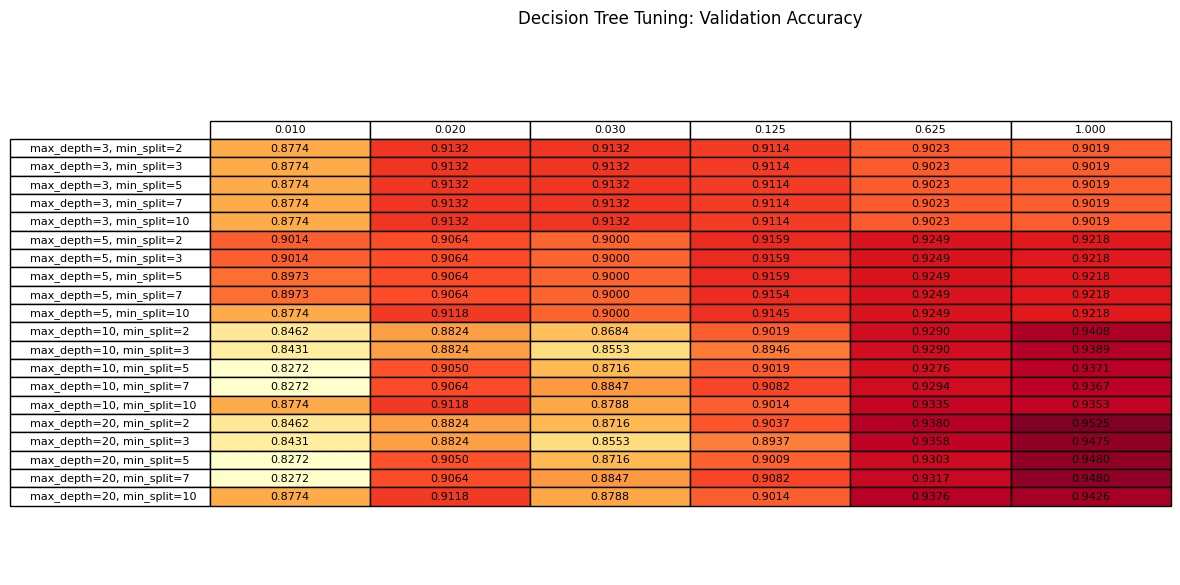

In [ ]:
row_keys_tree = sorted(stats_tree.keys())
row_labels_tree = [f"max_depth={d}, min_split={s}" for d, s in row_keys_tree]
cmap = plt.get_cmap("YlOrRd")
matrix_tree = []
for key in row_keys_tree:
    row = [next(acc for frac, acc in stats_tree[key] if frac == f) for f in fracs]
    matrix_tree.append(row)

acc_tree = np.array(matrix_tree)
normed_tree = (acc_tree - acc_tree.min()) / (acc_tree.max() - acc_tree.min() + 1e-12)
cell_colors_tree = [[cmap(v) for v in row] for row in normed_tree]

fig, ax = plt.subplots(figsize=(len(fracs) * 1.4 + 4, len(row_labels_tree) * 0.14 + 4))
ax.axis("off")

cell_text_tree = [[f"{value:.4f}" for value in row] for row in matrix_tree]
table = ax.table(
    cellText=cell_text_tree,
    cellColours=cell_colors_tree,
    rowLabels=row_labels_tree,
    colLabels=[f"{frac:.3f}" for frac in fracs],
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.1)
ax.set_title("Decision Tree Tuning: Validation Accuracy", pad=20)
plt.show()

In [12]:
class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, x, y):
        self.x_train = x
        self.y_train = y
    def predict(self, X):
        distances = np.linalg.norm(self.x_train[:, np.newaxis] - X, axis=2)
        nearest_indices = np.argsort(distances, axis=0)[:self.k]
        nearest_labels = self.y_train[nearest_indices]
        return np.array([most_common_label(nearest_labels[:, i]) for i in range(X.shape[0])])

In [24]:
k_vals = [3, 5, 7, 10, 15, 20 ]
fracs = [0.01, 0.02, 0.03, 0.125,0.625, 1]
stats_knn = {}
for k in k_vals:
    model = KNN(k=k)
    stats_knn[k] = []
    for frac in fracs:
        n_samples = int(frac * x_train.shape[0])
        model.fit(x_train[:n_samples], y_train[:n_samples])
        val_accuracy = np.mean(model.predict(x_val) == y_val)
        stats_knn[k].append((frac, val_accuracy))
        print(f"k: {k}, frac: {frac}, Validation Accuracy: {val_accuracy:.4f}")

k: 3, frac: 0.01, Validation Accuracy: 0.7512
k: 3, frac: 0.02, Validation Accuracy: 0.8327
k: 3, frac: 0.03, Validation Accuracy: 0.8422
k: 3, frac: 0.125, Validation Accuracy: 0.8869
k: 3, frac: 0.625, Validation Accuracy: 0.9335
k: 3, frac: 1, Validation Accuracy: 0.9444
k: 5, frac: 0.01, Validation Accuracy: 0.7657
k: 5, frac: 0.02, Validation Accuracy: 0.8548
k: 5, frac: 0.03, Validation Accuracy: 0.8630
k: 5, frac: 0.125, Validation Accuracy: 0.9068
k: 5, frac: 0.625, Validation Accuracy: 0.9331
k: 5, frac: 1, Validation Accuracy: 0.9444
k: 7, frac: 0.01, Validation Accuracy: 0.7829
k: 7, frac: 0.02, Validation Accuracy: 0.8625
k: 7, frac: 0.03, Validation Accuracy: 0.8706
k: 7, frac: 0.125, Validation Accuracy: 0.9032
k: 7, frac: 0.625, Validation Accuracy: 0.9335
k: 7, frac: 1, Validation Accuracy: 0.9448
k: 10, frac: 0.01, Validation Accuracy: 0.8290
k: 10, frac: 0.02, Validation Accuracy: 0.8512
k: 10, frac: 0.03, Validation Accuracy: 0.8566
k: 10, frac: 0.125, Validation Acc

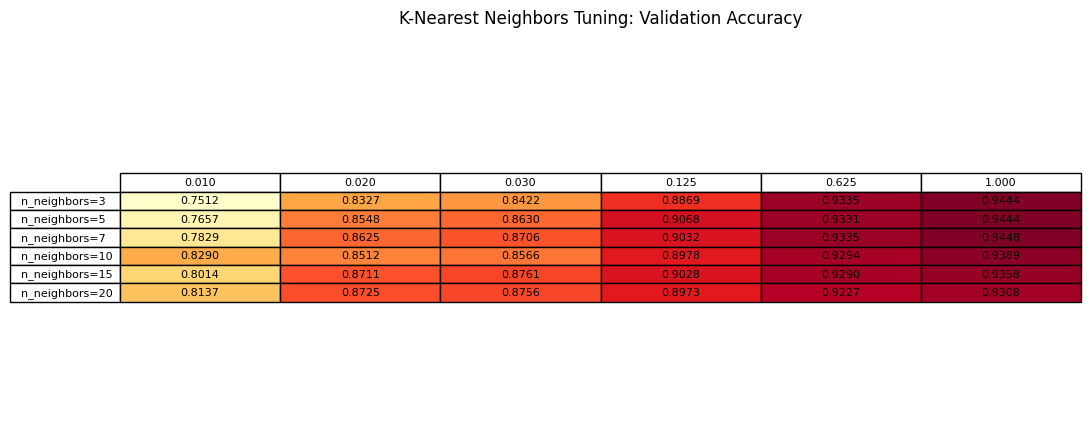

In [ ]:
row_keys_knn = sorted(stats_knn.keys())
row_labels_knn = [f"n_neighbors={n}" for n in row_keys_knn]
matrix_knn = []
for key in row_keys_knn:
    row = [next(acc for frac, acc in stats_knn[key] if frac == f) for f in fracs]
    matrix_knn.append(row)

acc_knn = np.array(matrix_knn)
normed_knn = (acc_knn - acc_knn.min()) / (acc_knn.max() - acc_knn.min() + 1e-12)
cell_colors_knn = [[cmap(v) for v in row] for row in normed_knn]

fig, ax = plt.subplots(figsize=(len(fracs) * 1.4 + 4, len(row_labels_knn) * 0.14 + 4))
ax.axis("off")

cell_text_knn = [[f"{value:.4f}" for value in row] for row in matrix_knn]
table = ax.table(
    cellText=cell_text_knn,
    cellColours=cell_colors_knn,
    rowLabels=row_labels_knn,
    colLabels=[f"{frac:.3f}" for frac in fracs],
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.1)
ax.set_title("K-Nearest Neighbors Tuning: Validation Accuracy", pad=20)
plt.show()

In [13]:
SVM_linear = SVM(C=0.1, kernel=linear_kernel(), tol=1e-4)
SVM_exp = SVM(C=10, kernel=exponential_kernel(gamma=0.1), tol=0.1)
decision_tree = DecisionTree(max_depth=20, min_samples_split=2)
k_nearest = KNN(k=7)
fracs = [0.01, 0.02, 0.03, 0.125,0.625, 1]
acc_linear = np.zeros(len(fracs))
acc_exp = np.zeros(len(fracs))
acc_tree = np.zeros(len(fracs))
acc_knn = np.zeros(len(fracs))
false_positives_linear = np.zeros(len(fracs))
false_positives_exp = np.zeros(len(fracs))
false_positives_tree = np.zeros(len(fracs))
false_positives_knn = np.zeros(len(fracs))
num_tests = 10
for t in range(num_tests):
    x_train, x_test, x_val, y_train, y_test, y_val = split_data(data, random_state=42+t)
    for i, frac in enumerate(fracs):
        n_samples = int(frac * x_train.shape[0])
        
        SVM_linear.fit(x_train[:n_samples], y_train[:n_samples])
        acc_linear[i] += np.mean(SVM_linear.predict(x_test) == y_test)
        false_positives_linear[i] += np.sum((SVM_linear.predict(x_test) == 1) & (y_test == -1))
        
        SVM_exp.fit(x_train[:n_samples], y_train[:n_samples])
        acc_exp[i] += np.mean(SVM_exp.predict(x_test) == y_test)
        false_positives_exp[i] += np.sum((SVM_exp.predict(x_test) == 1) & (y_test == -1))
        
        decision_tree.fit(x_train[:n_samples], y_train[:n_samples])
        acc_tree[i] += np.mean(decision_tree.predict(x_test) == y_test)
        false_positives_tree[i] += np.sum((decision_tree.predict(x_test) == 1) & (y_test == -1))
        
        k_nearest.fit(x_train[:n_samples], y_train[:n_samples])
        acc_knn[i] += np.mean(k_nearest.predict(x_test) == y_test)
        false_positives_knn[i] += np.sum((k_nearest.predict(x_test) == 1) & (y_test == -1))
acc_linear /= num_tests
acc_exp /= num_tests
acc_tree /= num_tests
acc_knn /= num_tests
false_positives_linear /= num_tests
false_positives_exp /= num_tests
false_positives_tree /= num_tests
false_positives_knn /= num_tests
        

[145.4 116.1 106.1 103.4 101.8 100.4]


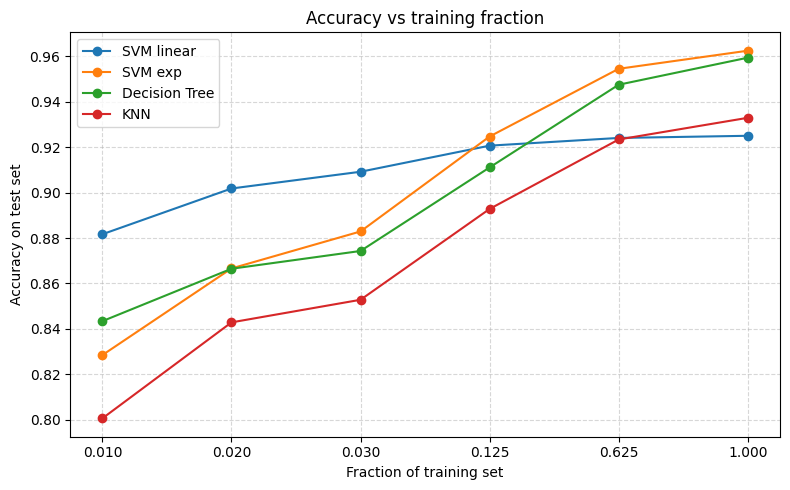

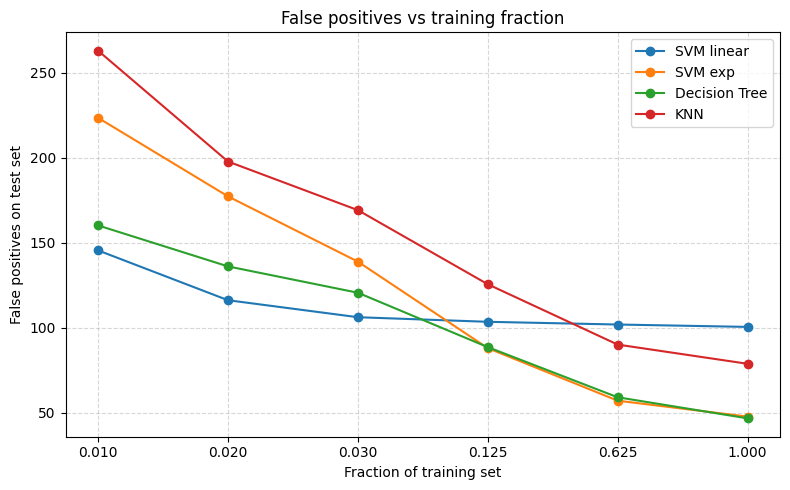

In [ ]:
x_positions = np.arange(len(fracs))
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x_positions, acc_linear, marker='o', label='SVM linear')
ax1.plot(x_positions, acc_exp, marker='o', label='SVM exp')
ax1.plot(x_positions, acc_tree, marker='o', label='Decision Tree')
ax1.plot(x_positions, acc_knn, marker='o', label='KNN')
ax1.set_xticks(x_positions)
ax1.set_xticklabels([f'{f:.3f}' for f in fracs])
ax1.set_xlabel('Fraction of training set')
ax1.set_ylabel('Accuracy on test set')
ax1.set_title('Accuracy vs training fraction')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(x_positions, false_positives_linear, marker='o', label='SVM linear')
ax2.plot(x_positions, false_positives_exp, marker='o', label='SVM exp')
ax2.plot(x_positions, false_positives_tree, marker='o', label='Decision Tree')
ax2.plot(x_positions, false_positives_knn, marker='o', label='KNN')
ax2.set_xticks(x_positions)
ax2.set_xticklabels([f'{f:.3f}' for f in fracs])
ax2.set_xlabel('Fraction of training set')
ax2.set_ylabel('False positives on test set')
ax2.set_title('False positives vs training fraction')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()